In [ ]:
"""
MBTA Bus Delay Prediction — XGBoost Pipeline
=============================================
- Stratified random sampling (handles ~26M rows)
- Feature engineering (temporal, route, stop-level)
- XGBoost regression for delay_seconds
- SHAP feature importance for actionable insights
- Summary plots saved as PNGs
"""

'\nMBTA Bus Delay Prediction — XGBoost Pipeline\n=============================================\n- Stratified random sampling (handles ~26M rows)\n- Feature engineering (temporal, route, stop-level)\n- XGBoost regression for delay_seconds\n- SHAP feature importance for actionable insights\n- Summary plots saved as PNGs\n'

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y, p): return mean_squared_error(y, p, squared=False)

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed — skipping SHAP plots.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
%matplotlib inline


In [ ]:
MBTA_FINAL       = Path("/content/drive/MyDrive/CS506 Project/mbta_final.csv")
TARGET_ROUTE_IDS = {"28", "23", "111", "15"}
SAMPLE_N_ROWS    = 500_000
RANDOM_STATE     = 42
STRATIFY_COL     = "route_id_str"

## 1. Stratified Random Sample

In [ ]:
def load_stratified_sample(path, n, strat_col, seed):
    """Proportional stratified random sample — no full load needed."""
    print("[1/6] Scanning strata counts …")
    chunk_size = 1_000_000
    strata_counts = {}

    # Determine the actual column(s) to load from CSV for strata scanning.
    # If `strat_col` is 'route_id_str', we need 'route_id' from the CSV to create it.
    # Otherwise, load `strat_col` directly.
    internal_strat_col_name = strat_col
    cols_to_read_for_first_pass = [strat_col]
    if strat_col == 'route_id_str':
        cols_to_read_for_first_pass = ['route_id']

    for chunk in pd.read_csv(path, usecols=cols_to_read_for_first_pass, chunksize=chunk_size, low_memory=False):
        # Create the internal stratification column if it's derived
        if strat_col == 'route_id_str':
            if 'route_id' in chunk.columns:
                chunk['route_id_str'] = chunk['route_id'].astype(str).str.strip()
            else:
                raise ValueError(f"Column 'route_id' not found in CSV for '{strat_col}' stratification. Please ensure 'route_id' exists.")
        else:
            # If strat_col is not derived, ensure it's a string and stripped.
            chunk[internal_strat_col_name] = chunk[internal_strat_col_name].astype(str).str.strip()

        vc = chunk[internal_strat_col_name].value_counts()
        for k, v in vc.items():
            strata_counts[k] = strata_counts.get(k, 0) + int(v)

    total = sum(strata_counts.values())
    quota = {k: max(1, round(v / total * n)) for k, v in strata_counts.items()}
    print(f"    Total rows: {total:,}  →  sampling {n:,}")

    print("[2/6] Collecting sample …")
    rng = np.random.default_rng(seed)
    collected, remaining = [], dict(quota)
    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        # For the actual collection loop, load all columns.
        # Then ensure `strat_col` exists and is cleaned within the chunk for grouping.
        if strat_col == 'route_id_str':
            if 'route_id' in chunk.columns:
                chunk['route_id_str'] = chunk['route_id'].astype(str).str.strip()
            else:
                raise ValueError(f"Column 'route_id' not found in chunk for stratification by '{strat_col}'.")

        # Standardize the column for grouping. This line handles both cases:
        # `strat_col` was created (e.g., 'route_id_str') or was loaded directly.
        chunk[internal_strat_col_name] = chunk[internal_strat_col_name].astype(str).str.strip()

        for key, sub in chunk.groupby(internal_strat_col_name, sort=False):
            need = remaining.get(key, 0)
            if need <= 0: continue
            take = min(need, len(sub))
            collected.append(sub.iloc[rng.choice(len(sub), take, replace=False)])
            remaining[key] -= take
        if all(v <= 0 for v in remaining.values()):
            break
    df = pd.concat(collected, ignore_index=True)
    print(f"    Sample shape: {df.shape}")
    return df

df = load_stratified_sample(MBTA_FINAL, SAMPLE_N_ROWS, STRATIFY_COL, RANDOM_STATE)
df["route_id_str"] = df["route_id"].astype(str).str.strip()

[1/6] Scanning strata counts …
    Total rows: 26,238,802  →  sampling 500,000
[2/6] Collecting sample …
    Sample shape: (499995, 18)


In [ ]:
# ── Config ───────────────────────────────────────────────────────────
from pathlib import Path

MBTA_FINAL       = Path("/content/drive/MyDrive/CS506 Project/mbta_final.csv")
SURVEY_PATH      = Path("/content/drive/MyDrive/CS506 Project/MBTA_2024_System-Wide_Passenger_Survey.csv")
TARGET_ROUTE_IDS = {"28", "23", "111", "15"}
SAMPLE_N_ROWS    = 500_000
RANDOM_STATE     = 42
STRATIFY_COL     = "route_id_str"

# New response variable: average delay (in minutes) aggregated per stop-route-hour
RESPONSE         = "avg_delay_min"

## 2. Feature Engineering

New predictors added:
- **Demographic equity**: ,  (Title VI from survey)
- **Stop-level**:  (encoded stop ID)
- **Historical delay**: rolling mean delay per route-hour () and per stop ()
- **Response**:  — mean delay in minutes aggregated per route × stop × hour × day-of-week

In [ ]:
import re

# ── 2a. Load demographic survey data ──────────────────────────────────
def load_demographics(survey_path):
    """Returns a DataFrame with route_id, pct_low_income, pct_minority."""
    survey = pd.read_csv(survey_path)

    def get_route_share(measure_name):
        sub = survey[
            (survey["service_mode"] == "Bus") &
            (survey["measure"] == measure_name) &
            (survey["aggregation_level"] == "Reporting Group") &
            (survey["category"] == "Yes")
        ].copy()
        sub = sub[sub["reporting_group"].str.match(r"^[\d,&\s]+$")].copy()
        rows = []
        for _, row in sub.iterrows():
            for rid in re.split(r"[,&]", row["reporting_group"]):
                rid = rid.strip()
                if rid:
                    rows.append({"route_id": rid, "value": row["weighted_percent"]})
        return pd.DataFrame(rows).rename(columns={"value": measure_name.lower().replace(" ", "_")})

    income   = get_route_share("Title VI Low-Income")
    minority = get_route_share("Title VI Minority")
    demo = income.merge(minority, on="route_id", how="outer")
    demo.columns = ["route_id", "pct_low_income", "pct_minority"]
    print(f"[demo] Routes with demographic data: {len(demo)}")
    return demo

demo_df = load_demographics(SURVEY_PATH)
print(demo_df.head())

[demo] Routes with demographic data: 30
  route_id  pct_low_income  pct_minority
0        1        0.825452      0.665510
1       10        0.756001      0.411511
2      104        0.885860      0.778772
3       11        0.553478      0.444401
4      111        0.904575      0.826846


In [ ]:
# ── 2b. Engineer features ─────────────────────────────────────────────
def engineer_features(df, demo_df):
    print("[3/6] Engineering features …")

    # Parse timestamps
    df["scheduled"]    = pd.to_datetime(df["scheduled"],    errors="coerce")
    df["actual"]       = pd.to_datetime(df["actual"],       errors="coerce")
    df["service_date"] = pd.to_datetime(df["service_date"], errors="coerce")
    df["delay_seconds"] = (df["actual"] - df["scheduled"]).dt.total_seconds().clip(-3600, 10800)

    # Temporal features
    df["hour"]        = df["scheduled"].dt.hour
    df["day_of_week"] = df["service_date"].dt.dayofweek
    df["month"]       = df["service_date"].dt.month
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    df["is_peak"]     = (df["hour"].isin(range(7, 10)) | df["hour"].isin(range(16, 19))).astype(int)

    # Categorical encoding
    cat_cols = ["route_id_str", "direction_id", "point_type",
                "standard_type", "neighborhood", "municipality", "stop_id"]
    le_dict = {}
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
            le = LabelEncoder()
            df[f"{col}_enc"] = le.fit_transform(df[col].fillna("__missing__"))
            le_dict[col] = le

    # ── Historical delay features ──────────────────────────────────────
    # Route × hour mean delay (leave-one-out via global mean; robust for unseen combos)
    route_hour_mean = (
        df.groupby(["route_id_str", "hour"])["delay_seconds"]
        .transform("mean")
    )
    df["hist_delay_route_hour"] = route_hour_mean

    # Stop mean delay
    if "stop_id" in df.columns:
        df["hist_delay_stop"] = df.groupby("stop_id")["delay_seconds"].transform("mean")
    else:
        df["hist_delay_stop"] = np.nan

    # Route × day-of-week mean delay
    df["hist_delay_route_dow"] = df.groupby(["route_id_str", "day_of_week"])["delay_seconds"].transform("mean")

    # ── Merge demographic features ─────────────────────────────────────
    df["route_id_str_clean"] = df["route_id"].astype(str).str.strip()
    df = df.merge(demo_df, left_on="route_id_str_clean", right_on="route_id", how="left", suffixes=("", "_demo"))
    print(f"   Routes matched to demographic data: {df['pct_low_income'].notna().sum():,} / {len(df):,} rows")

    return df

df = engineer_features(df, demo_df)
df[["hour", "is_peak", "is_weekend", "delay_seconds",
    "hist_delay_route_hour", "hist_delay_stop",
    "pct_low_income", "pct_minority"]].describe()

[3/6] Engineering features …
   Routes matched to demographic data: 191,677 / 499,995 rows


,hour,is_peak,is_weekend,delay_seconds,hist_delay_route_hour,hist_delay_stop,pct_low_income,pct_minority
count,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,191677.000000,191677.000000
mean,12.943159,0.380128,0.193682,95.926733,95.926733,95.926733,0.842777,0.718713
std,5.602837,0.485419,0.395183,312.226712,124.856172,99.588297,0.081740,0.149369
min,0.000000,0.000000,0.000000,-3600.000000,-1795.000000,-672.880000,0.553478,0.411511
25%,8.000000,0.000000,0.000000,-40.000000,24.238876,32.343216,0.819705,0.603521
50%,13.000000,0.000000,0.000000,69.000000,91.936306,89.000415,0.879625,0.778772
75%,17.000000,1.000000,0.000000,215.000000,158.757440,158.025210,0.904575,0.854924
max,23.000000,1.000000,1.000000,10800.000000,2340.476190,992.333333,0.943912,0.883537


In [ ]:
# ── 2c. Build response variable: avg_delay_min ────────────────────────
# Aggregate to route × stop × hour × day_of_week level
# Response = mean delay in MINUTES for each stratum

group_keys = ["route_id_str", "hour", "day_of_week", "is_weekend", "is_peak"]
if "stop_id" in df.columns:
    group_keys.insert(1, "stop_id")

static_feats = [
    "route_id_str_enc", "direction_id_enc", "point_type_enc",
    "standard_type_enc", "neighborhood_enc", "municipality_enc",
    "time_point_order", "month",
    "pct_low_income", "pct_minority",
    "hist_delay_route_hour", "hist_delay_route_dow",
]
if "stop_id_enc" in df.columns:
    static_feats.insert(0, "stop_id_enc")
if "hist_delay_stop" in df.columns:
    static_feats.append("hist_delay_stop")

# Aggregate
agg_dict = {"delay_seconds": "mean"}
for f in static_feats:
    if f in df.columns:
        agg_dict[f] = "first"

df_agg = (
    df.groupby(group_keys)
    .agg(agg_dict)
    .reset_index()
    .rename(columns={"delay_seconds": "avg_delay_s"})
)
df_agg["avg_delay_min"] = df_agg["avg_delay_s"] / 60

print(f"Aggregated dataset shape: {df_agg.shape}")
df_agg[["avg_delay_s", "avg_delay_min"]].describe()

Aggregated dataset shape: (168420, 22)


,avg_delay_s,avg_delay_min
count,168420.000000,168420.000000
mean,106.636935,1.777282
std,266.181578,4.436360
min,-3600.000000,-60.000000
25%,-16.517857,-0.275298
50%,86.000000,1.433333
75%,210.000000,3.500000
max,5325.500000,88.758333


In [ ]:
# ── 2d. Define feature columns for model ──────────────────────────────
FEATURE_COLS = [
    # Temporal
    "hour", "day_of_week", "month", "is_weekend", "is_peak",
    # Route / stop / network
    "route_id_str_enc", "direction_id_enc", "point_type_enc",
    "standard_type_enc", "neighborhood_enc", "municipality_enc",
    "time_point_order",
    # Demographic (Title VI equity)
    "pct_low_income", "pct_minority",
    # Historical delay
    "hist_delay_route_hour", "hist_delay_route_dow",
    # Stop-level (included if stop_id column exists)
    "stop_id_enc", "hist_delay_stop",
]
print("Feature columns defined:", len(FEATURE_COLS))

Feature columns defined: 18


## 3. Training (response=avg_delay_min)

In [ ]:
def train_xgb(df_agg):
    print("[4/6] Training XGBoost on avg_delay_min …")
    target = RESPONSE   # "avg_delay_min"
    feats  = [c for c in FEATURE_COLS if c in df_agg.columns]
    clean  = df_agg[feats + [target]].dropna()
    X, y   = clean[feats], clean[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)

    model = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.08, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = root_mean_squared_error(y_test, preds)
    r2    = r2_score(y_test, preds)

    print(f"    MAE:  {mae:.3f} min")
    print(f"    RMSE: {rmse:.3f} min")
    print(f"    R²:   {r2:.3f}")
    return model, X_test, y_test, preds, feats, mae, rmse, r2

model, X_test, y_test, preds, feats, mae, rmse, r2 = train_xgb(df_agg)

[4/6] Training XGBoost on avg_delay_min …
    MAE:  1.796 min
    RMSE: 2.750 min
    R²:   0.616


## 3b. Adjusted R^2

Tests each feature group incrementally on **held-out data** (5-fold CV). A feature that raises R² but lowers adjusted R² is adding noise — a sign of overfitting.

**Adjusted R²** penalises extra predictors: penalises for k features in n samples.

We also report the **train vs test R² gap** — a large gap (>0.05) signals overfitting.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings

def adjusted_r2(r2_val, n, k):
    if n - k - 1 <= 0:
        return float("nan")
    return 1 - (1 - r2_val) * (n - 1) / (n - k - 1)

def cv_metrics(X, y, model_params, cv=5, random_state=RANDOM_STATE):
    """5-fold CV: returns (mean_test_r2, mean_train_r2, adj_r2, gap)."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    train_r2s, test_r2s = [], []
    for tr_idx, te_idx in kf.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
        m = xgb.XGBRegressor(**model_params)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m.fit(X_tr, y_tr, verbose=False)
        train_r2s.append(r2_score(y_tr, m.predict(X_tr)))
        test_r2s.append(r2_score(y_te, m.predict(X_te)))
    mean_test  = float(np.mean(test_r2s))
    mean_train = float(np.mean(train_r2s))
    adj = adjusted_r2(mean_test, len(y), X.shape[1])
    return mean_test, mean_train, adj, mean_train - mean_test

In [ ]:
# Feature groups added cumulatively (forward selection order)
FEATURE_GROUPS = [
    ("Temporal",
     ["hour", "day_of_week", "month", "is_weekend", "is_peak"]),
    ("+ Route / Stop / Network",
     ["route_id_str_enc", "direction_id_enc", "point_type_enc",
      "standard_type_enc", "neighborhood_enc", "municipality_enc", "time_point_order"]),
    ("+ Stop ID",
     ["stop_id_enc"]),
    ("+ Demographic (pct_low_income, pct_minority)",
     ["pct_low_income", "pct_minority"]),
    ("+ Historical delay (route x hour, route x dow)",
     ["hist_delay_route_hour", "hist_delay_route_dow"]),
    ("+ Historical delay (stop)",
     ["hist_delay_stop"]),
]

XGB_PARAMS = dict(
    n_estimators=400, learning_rate=0.08, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
)

# Build clean dataset with all possible features
all_feats = [f for _, grp in FEATURE_GROUPS for f in grp]
avail     = [f for f in all_feats if f in df_agg.columns]
clean     = df_agg[avail + [RESPONSE]].dropna()
y_full    = clean[RESPONSE]
print(f"Clean rows for adj-R2 check: {len(clean):,}")

# Forward accumulation
results      = []
active_feats = []

for group_name, group_feats in FEATURE_GROUPS:
    new_f = [f for f in group_feats if f in clean.columns]
    if not new_f:
        print(f"  SKIP {group_name!r} — not in data")
        continue
    active_feats = active_feats + new_f
    cv_r2, tr_r2, adj, gap = cv_metrics(clean[active_feats], y_full, XGB_PARAMS)
    flag = "  <<< overfit?" if gap > 0.05 else ""
    print(f"  k={len(active_feats):>2}  CV-R2={cv_r2:.4f}  TrainR2={tr_r2:.4f}  AdjR2={adj:.4f}  gap={gap:.4f}{flag}")
    results.append({
        "Group": group_name,
        "k": len(active_feats),
        "CV Test R2": round(cv_r2, 4),
        "Train R2": round(tr_r2, 4),
        "Adj R2": round(adj, 4),
        "Gap": round(gap, 4),
    })

results_df = pd.DataFrame(results)
print("\n=== Full Results ===")
print(results_df.to_string(index=False))

Clean rows for adj-R2 check: 45,264
  k= 5  CV-R2=0.1804  TrainR2=0.1880  AdjR2=0.1803  gap=0.0077
  k=12  CV-R2=0.5680  TrainR2=0.6569  AdjR2=0.5679  gap=0.0889  <<< overfit?
  k=13  CV-R2=0.5653  TrainR2=0.6672  AdjR2=0.5652  gap=0.1019  <<< overfit?
  k=15  CV-R2=0.5814  TrainR2=0.6820  AdjR2=0.5812  gap=0.1006  <<< overfit?
  k=17  CV-R2=0.6112  TrainR2=0.7342  AdjR2=0.6110  gap=0.1231  <<< overfit?
  k=18  CV-R2=0.6088  TrainR2=0.7388  AdjR2=0.6086  gap=0.1300  <<< overfit?

=== Full Results ===
                                         Group  k  CV Test R2  Train R2  Adj R2    Gap
                                      Temporal  5      0.1804    0.1880  0.1803 0.0077
                      + Route / Stop / Network 12      0.5680    0.6569  0.5679 0.0889
                                     + Stop ID 13      0.5653    0.6672  0.5652 0.1019
  + Demographic (pct_low_income, pct_minority) 15      0.5814    0.6820  0.5812 0.1006
+ Historical delay (route x hour, route x dow) 17      0.61

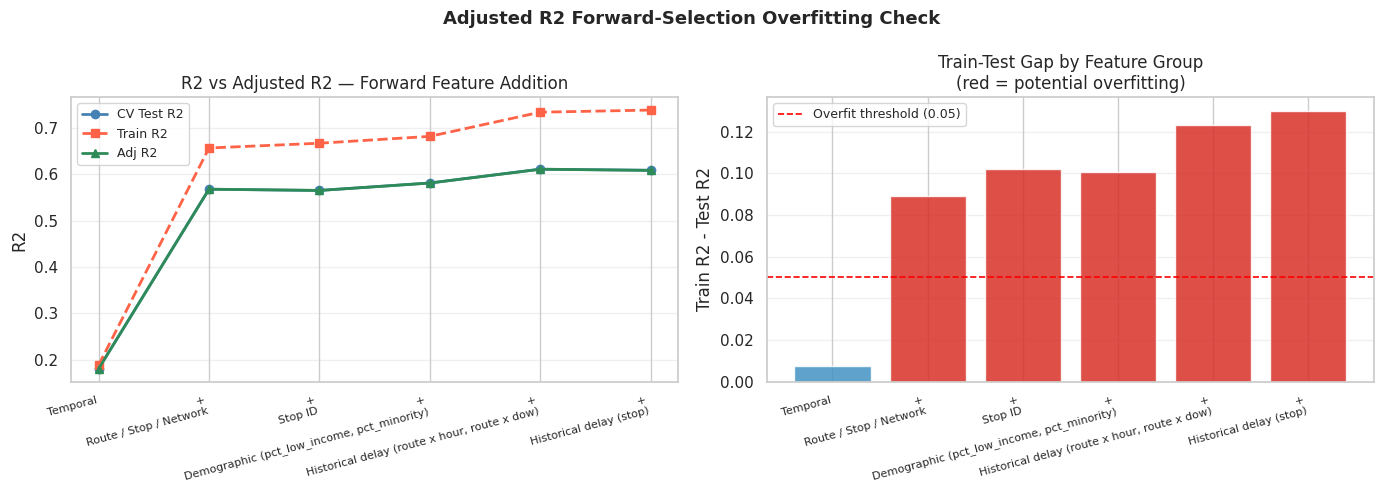

In [ ]:
# ── Visualise forward-selection results ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels    = [r["Group"] for r in results]
short_lbl = [l.replace("+ ", "+\n") for l in labels]
x         = list(range(len(results)))

# Left: R² curves
ax = axes[0]
ax.plot(x, [r["CV Test R2"] for r in results], "o-",  color="steelblue", lw=2, label="CV Test R2")
ax.plot(x, [r["Train R2"]   for r in results], "s--", color="tomato",    lw=2, label="Train R2")
ax.plot(x, [r["Adj R2"]     for r in results], "^-",  color="seagreen",  lw=2, label="Adj R2")
ax.set_xticks(x)
ax.set_xticklabels(short_lbl, fontsize=8, rotation=15, ha="right")
ax.set_ylabel("R2")
ax.set_title("R2 vs Adjusted R2 — Forward Feature Addition")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Right: Train-Test Gap
ax2 = axes[1]
gap_vals   = [r["Gap"] for r in results]
bar_colors = ["#d73027" if g > 0.05 else "#4393c3" for g in gap_vals]
ax2.bar(x, gap_vals, color=bar_colors, edgecolor="white", alpha=0.85)
ax2.axhline(0.05, color="red", ls="--", lw=1.2, label="Overfit threshold (0.05)")
ax2.set_xticks(x)
ax2.set_xticklabels(short_lbl, fontsize=8, rotation=15, ha="right")
ax2.set_ylabel("Train R2 - Test R2")
ax2.set_title("Train-Test Gap by Feature Group\n(red = potential overfitting)")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Adjusted R2 Forward-Selection Overfitting Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Interpretation printout ─────────────────────────────
print("=== Feature Group Verdicts ===")
for i, r in enumerate(results):
    prev_adj = results[i-1]["Adj R2"] if i > 0 else 0.0
    delta    = r["Adj R2"] - prev_adj
    if delta > 0.005:
        verdict = "USEFUL    -- adj R2 improved meaningfully"
    elif delta >= 0:
        verdict = "MARGINAL  -- tiny adj R2 gain (<0.005)"
    else:
        verdict = "HURTS     -- adj R2 dropped (adds noise/overfit)"
    overfit = "  [overfit gap!]" if r["Gap"] > 0.05 else ""
    print(f"  {r['Group']:<48}  delta_adjR2={delta:+.4f}  {verdict}{overfit}")


=== Feature Group Verdicts ===
  Temporal                                          delta_adjR2=+0.1803  USEFUL    -- adj R2 improved meaningfully
  + Route / Stop / Network                          delta_adjR2=+0.3876  USEFUL    -- adj R2 improved meaningfully  [overfit gap!]
  + Stop ID                                         delta_adjR2=-0.0027  HURTS     -- adj R2 dropped (adds noise/overfit)  [overfit gap!]
  + Demographic (pct_low_income, pct_minority)      delta_adjR2=+0.0160  USEFUL    -- adj R2 improved meaningfully  [overfit gap!]
  + Historical delay (route x hour, route x dow)    delta_adjR2=+0.0298  USEFUL    -- adj R2 improved meaningfully  [overfit gap!]
  + Historical delay (stop)                         delta_adjR2=-0.0024  HURTS     -- adj R2 dropped (adds noise/overfit)  [overfit gap!]


## 4. Visualizations

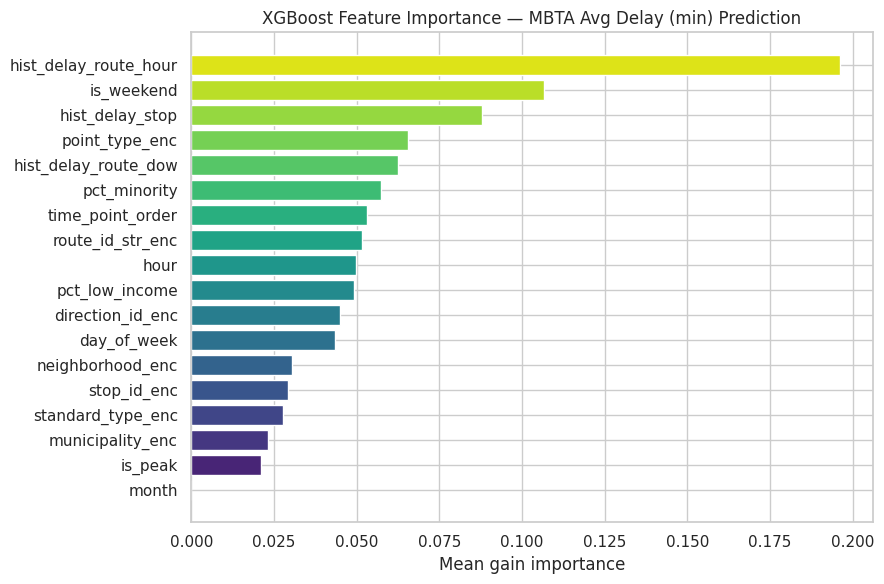

In [ ]:
# Feature Importance
imp = pd.DataFrame({"feature": feats, "importance": model.feature_importances_}) \
        .sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("viridis", len(imp))
ax.barh(imp["feature"], imp["importance"], color=colors)
ax.set_xlabel("Mean gain importance")
ax.set_title("XGBoost Feature Importance — MBTA Avg Delay (min) Prediction")
plt.tight_layout()
plt.show()

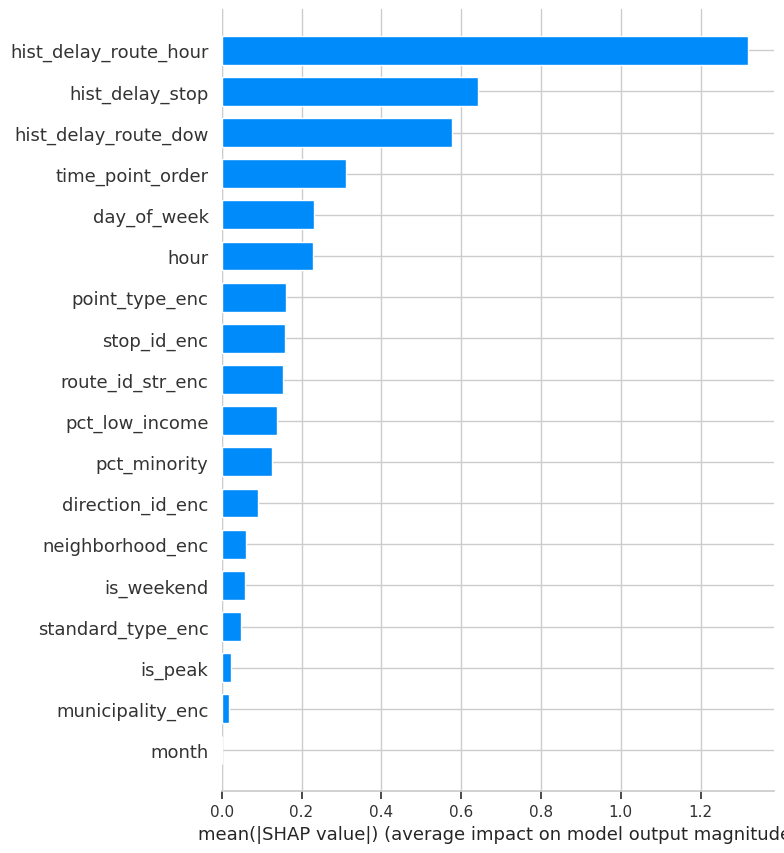

In [ ]:
# SHAP Summary (bar)
if HAS_SHAP:
    explainer = shap.TreeExplainer(model)
    shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
    sv = explainer.shap_values(shap_sample)
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv, shap_sample, plot_type="bar", show=True)
else:
    print("Install shap to see SHAP plots: !pip install shap")

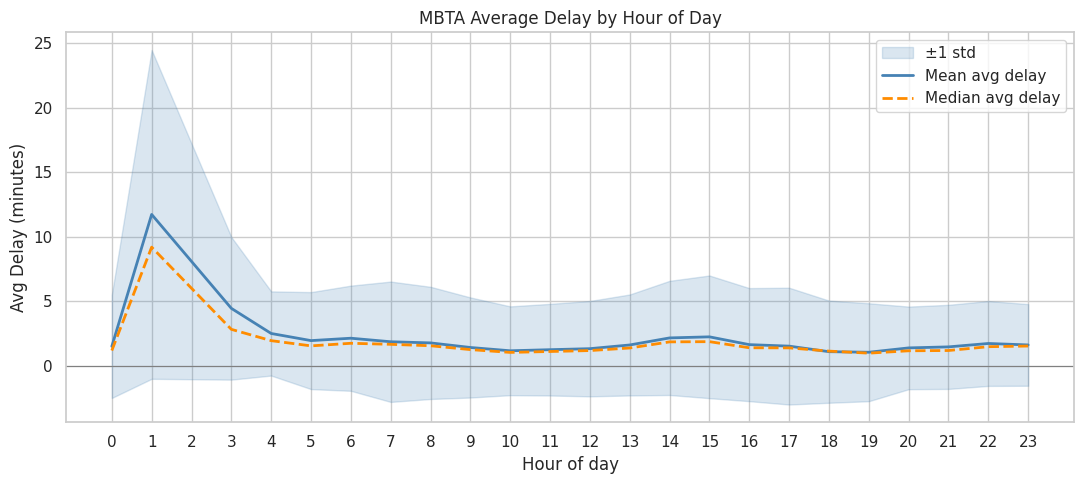

In [ ]:
# Avg Delay by Hour of Day (aggregated response)
grp = df_agg.groupby("hour")["avg_delay_min"].agg(["mean", "median", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(grp["hour"], grp["mean"] - grp["std"], grp["mean"] + grp["std"],
                alpha=0.2, color="steelblue", label="±1 std")
ax.plot(grp["hour"], grp["mean"],   color="steelblue",  lw=2,       label="Mean avg delay")
ax.plot(grp["hour"], grp["median"], color="darkorange", lw=2, ls="--", label="Median avg delay")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg Delay (minutes)")
ax.set_title("MBTA Average Delay by Hour of Day")
ax.legend()
plt.tight_layout()
plt.show()

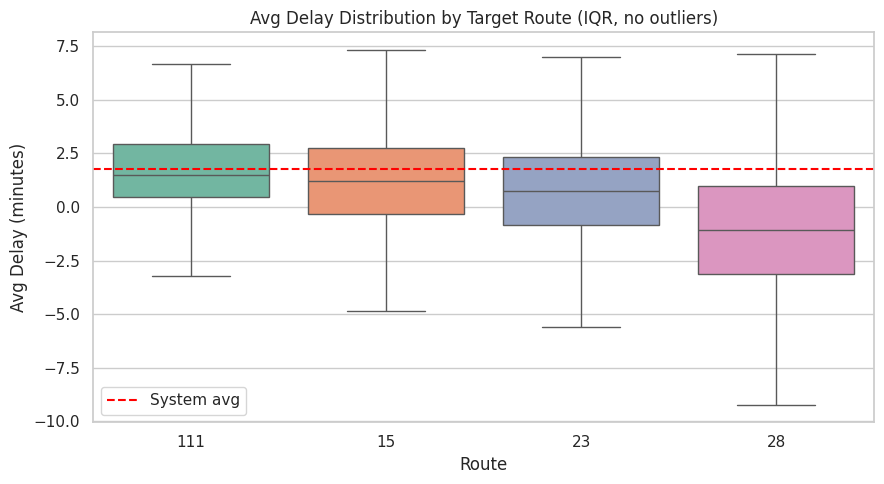

In [ ]:
# Avg Delay by Target Route
target_agg = df_agg[df_agg["route_id_str"].isin(TARGET_ROUTE_IDS)].copy()
order = target_agg.groupby("route_id_str")["avg_delay_min"].mean() \
                   .sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=target_agg, x="route_id_str", y="avg_delay_min",
            order=order, hue="route_id_str", palette="Set2",
            ax=ax, showfliers=False, legend=False)
ax.axhline(df_agg["avg_delay_min"].mean(), color="red", ls="--", label="System avg")
ax.set_title("Avg Delay Distribution by Target Route (IQR, no outliers)")
ax.set_xlabel("Route")
ax.set_ylabel("Avg Delay (minutes)")
ax.legend()
plt.tight_layout()
plt.show()

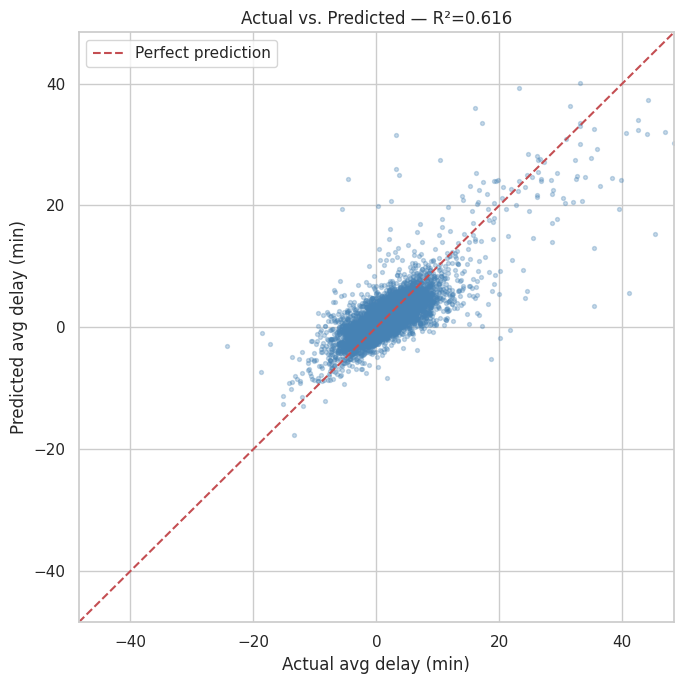

In [ ]:
# Actual vs Predicted (avg_delay_min)
lim = min(max(abs(y_test.values).max(), abs(preds).max()), 60)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds, alpha=0.3, s=8, color="steelblue")
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Actual avg delay (min)")
ax.set_ylabel("Predicted avg delay (min)")
ax.set_title(f"Actual vs. Predicted — R²={r2:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

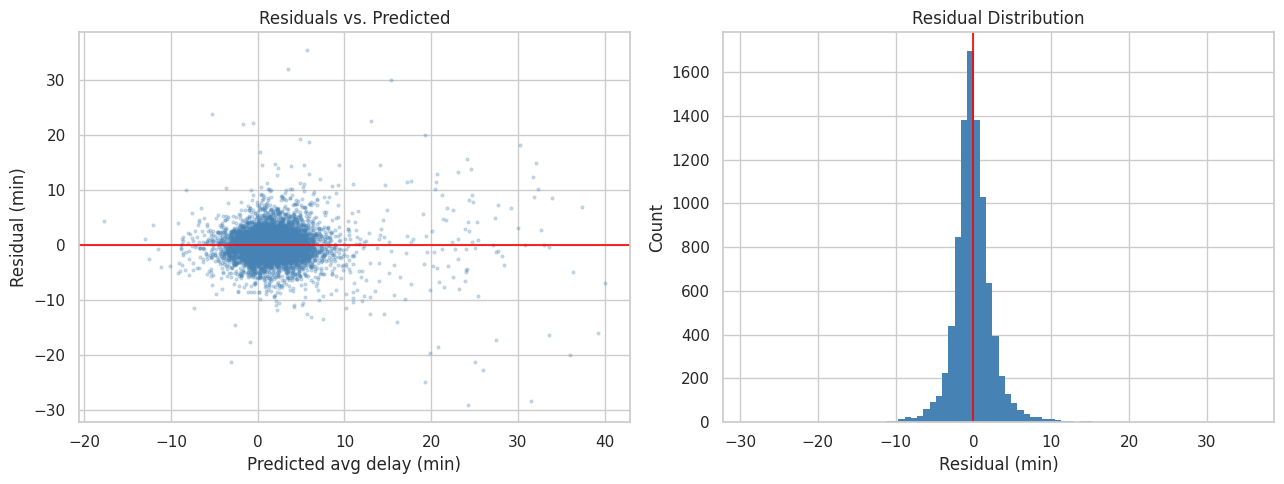

In [ ]:
# Residuals
residuals = y_test.values - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(preds, residuals, alpha=0.25, s=4, color="steelblue")
axes[0].axhline(0, color="red", lw=1.2)
axes[0].set_xlabel("Predicted avg delay (min)")
axes[0].set_ylabel("Residual (min)")
axes[0].set_title("Residuals vs. Predicted")

axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="none")
axes[1].axvline(0, color="red", lw=1.2)
axes[1].set_xlabel("Residual (min)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 5. Demographic Equity Analysis

In [ ]:
# Merge route-level avg delay with demographics
route_delays = (
    df_agg.groupby("route_id_str")["avg_delay_min"]
    .agg(mean_delay="mean", median_delay="median", n_obs="count")
    .reset_index()
    .rename(columns={"route_id_str": "route_id"})
)

merged = route_delays.merge(demo_df, on="route_id", how="inner")
print(f"Routes matched: {len(merged)}")
print(merged.sort_values("pct_low_income", ascending=False).to_string(index=False))

Routes matched: 26
route_id  mean_delay  median_delay  n_obs  pct_low_income  pct_minority
      23    1.168353      0.744444   2657        0.943912      0.854924
      28   -0.477617     -1.077083   2954        0.909279      0.881898
      29    2.518664      1.850000   1316        0.909279      0.881898
      21    2.718368      2.616667   1300        0.904860      0.880522
     111    1.918957      1.478571   2656        0.904575      0.826846
      32    2.227691      1.508974   1567        0.903795      0.831415
      15    1.396001      1.190833   1882        0.898127      0.883537
     116    0.420858      0.183333   1387        0.893456      0.755908
     117    0.784430      0.618750   1718        0.893456      0.755908
     114    2.505013      1.695833    192        0.893456      0.755908
     104    2.372223      1.900000   1512        0.885860      0.778772
      71    1.732315      1.166667   1693        0.879625      0.554028
      86   -0.339661      0.400000   1584    

In [ ]:
# Income Tier Classification
# Define income tiers based on Title VI low-income share
# (Title VI threshold is typically ~80% AMI or below)
def classify_income_tier(pct):
    if pct >= 0.85:
        return "High Low-Income (≥85%)"
    elif pct >= 0.70:
        return "Moderate Low-Income (70–85%)"
    else:
        return "Lower Low-Income (<70%)"

merged["income_tier"] = merged["pct_low_income"].apply(classify_income_tier)

tier_summary = (
    merged.groupby("income_tier")
    .agg(
        n_routes=("route_id", "count"),
        mean_delay_s=("mean_delay", "mean"),
        median_delay_s=("median_delay", "median"),
        routes=("route_id", lambda x: ", ".join(sorted(x))),
    )
    .reset_index()
)

tier_summary["mean_delay_min"] = tier_summary["mean_delay_s"] / 60
print("\n=== Delay by Income Tier ===")
print(tier_summary[["income_tier", "n_routes", "mean_delay_s", "mean_delay_min", "routes"]].to_string(index=False))


=== Delay by Income Tier ===
                 income_tier  n_routes  mean_delay_s  mean_delay_min                                              routes
      High Low-Income (≥85%)        12      1.607105        0.026785 104, 111, 114, 116, 117, 15, 21, 23, 28, 29, 32, 71
     Lower Low-Income (<70%)         1      3.930107        0.065502                                                  11
Moderate Low-Income (70–85%)        13      1.918962        0.031983  10, 16, 22, 39, 47, 57, 61, 66, 67, 70, 73, 77, 86


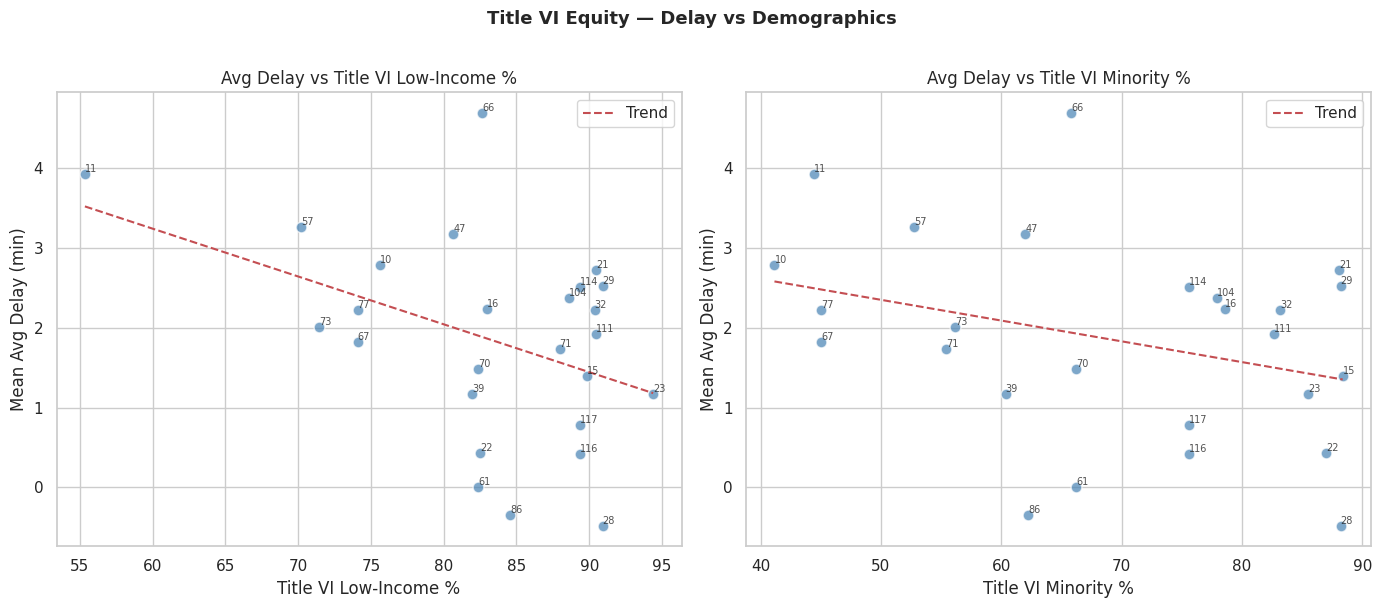

In [ ]:
# Scatter: Avg Delay vs Low-Income % and Minority %
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_col, label in zip(
    axes,
    ["pct_low_income", "pct_minority"],
    ["Title VI Low-Income %", "Title VI Minority %"]
):
    ax.scatter(merged[x_col] * 100, merged["mean_delay"],
               s=60, alpha=0.7, color="steelblue", edgecolors="white")
    for _, row in merged.iterrows():
        ax.annotate(row["route_id"],
                    (row[x_col] * 100, row["mean_delay"]),
                    fontsize=7, ha="left", va="bottom", alpha=0.8)
    # Trend line
    mask = merged[x_col].notna() & merged["mean_delay"].notna()
    z = np.polyfit(merged.loc[mask, x_col] * 100, merged.loc[mask, "mean_delay"], 1)
    p = np.poly1d(z)
    xs = np.linspace(merged[x_col].min() * 100, merged[x_col].max() * 100, 100)
    ax.plot(xs, p(xs), "r--", lw=1.5, label=f"Trend")
    ax.set_xlabel(label)
    ax.set_ylabel("Mean Avg Delay (min)")
    ax.set_title(f"Avg Delay vs {label}")
    ax.legend()

plt.suptitle("Title VI Equity — Delay vs Demographics", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Delay by neighborhood & Municipality

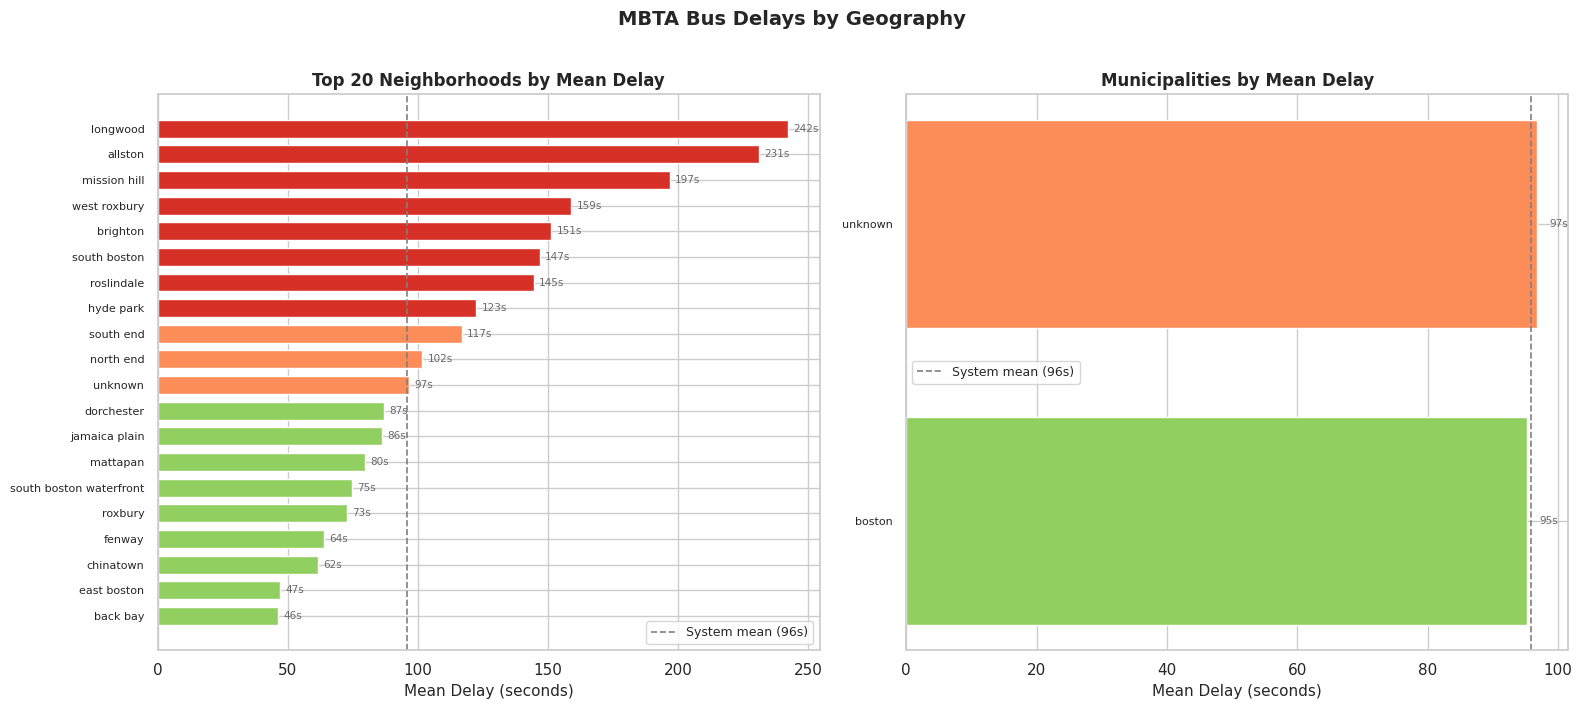

In [ ]:
# ── A: Delay by Neighborhood & Municipality ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

TOP_N = 20

for ax, col, title in zip(
    axes,
    ["neighborhood", "municipality"],
    ["Top 20 Neighborhoods by Mean Delay", "Municipalities by Mean Delay"],
):
    if col not in df.columns:
        ax.text(0.5, 0.5, f"Column '{col}' not in df", ha="center", va="center")
        ax.set_title(title)
        continue

    grp = (
        df.groupby(col)["delay_seconds"]
        .agg(mean_delay="mean", n_obs="count")
        .reset_index()
        .query("n_obs >= 500")          # filter low-sample groups
        .sort_values("mean_delay", ascending=True)
        .tail(TOP_N)
    )

    overall_mean = df["delay_seconds"].mean()

    colors = [
        "#d73027" if v > overall_mean * 1.25
        else "#fc8d59" if v > overall_mean
        else "#91cf60"
        for v in grp["mean_delay"]
    ]

    bars = ax.barh(grp[col], grp["mean_delay"], color=colors, edgecolor="white", height=0.7)
    ax.axvline(overall_mean, color="gray", ls="--", lw=1.2, label=f"System mean ({overall_mean:.0f}s)")

    for bar, val in zip(bars, grp["mean_delay"]):
        ax.text(
            val + 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}s", va="center", fontsize=7.5, color="dimgray"
        )

    ax.set_xlabel("Mean Delay (seconds)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("MBTA Bus Delays by Geography", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

##7. Delay Heatmap: Route x Hour

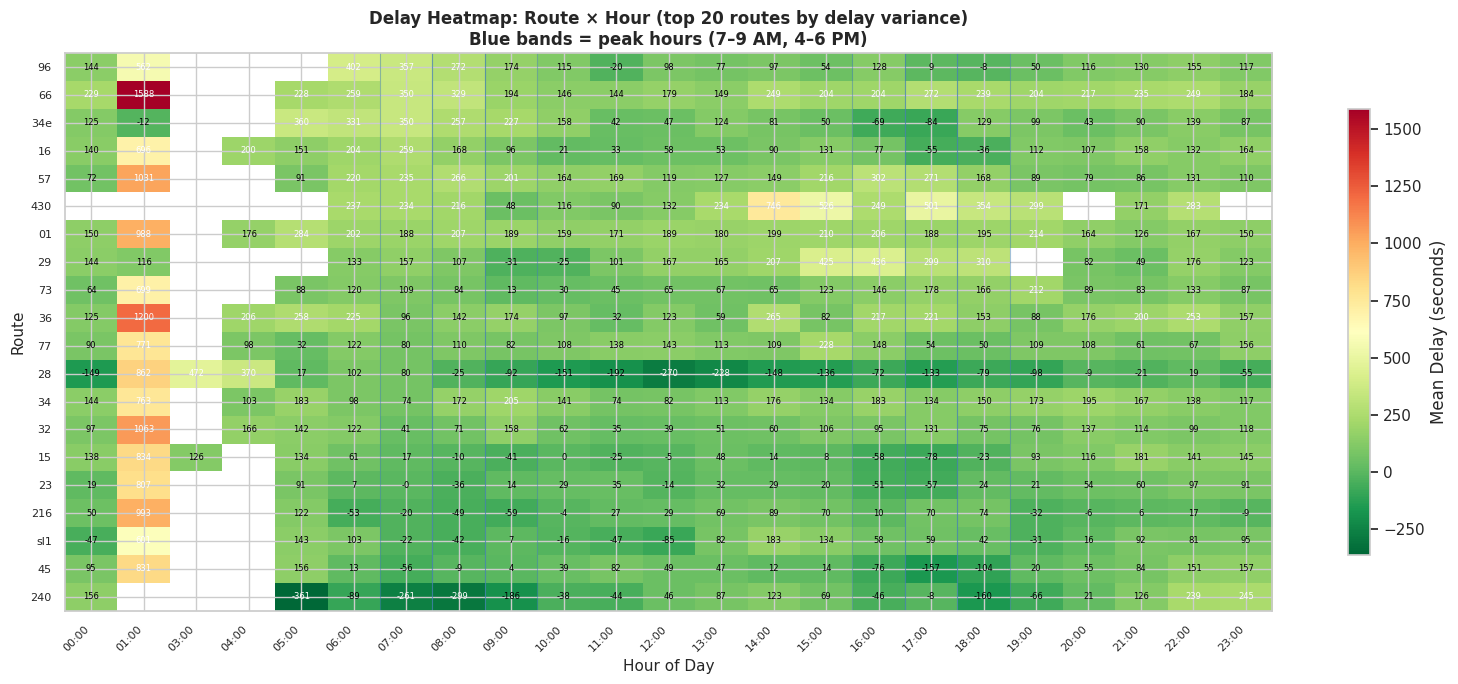

In [ ]:
# ── B: Delay Heatmap — Route × Hour ─────────────────────────────────

# Use target routes + any route with enough data
MIN_OBS_PER_CELL = 50
TOP_ROUTES = 20   # show top N routes by overall mean delay variance

# Pivot: rows = route, cols = hour
heatmap_df = (
    df.groupby(["route_id_str", "hour"])["delay_seconds"]
    .agg(mean_delay="mean", n="count")
    .reset_index()
    .query("n >= @MIN_OBS_PER_CELL")
)

pivot = heatmap_df.pivot(index="route_id_str", columns="hour", values="mean_delay")

# Keep routes that have data for at least 16 hours and highest variance
pivot = pivot[pivot.notna().sum(axis=1) >= 16]
top_routes = pivot.var(axis=1).nlargest(TOP_ROUTES).index
pivot = pivot.loc[top_routes].sort_values(by=list(range(7, 10)), ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))

im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")

# Axes labels
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels([f"{int(c):02d}:00" for c in pivot.columns], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)

# Annotate cells with values
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=6, color="white" if abs(val) > 200 else "black")

# Shade peak hours
for ph in list(range(7, 10)) + list(range(16, 19)):
    if ph - pivot.columns[0] < pivot.shape[1]:
        col_idx = list(pivot.columns).index(ph) if ph in pivot.columns else None
        if col_idx is not None:
            ax.axvline(col_idx - 0.5, color="steelblue", lw=0.8, alpha=0.5)
            ax.axvline(col_idx + 0.5, color="steelblue", lw=0.8, alpha=0.5)

plt.colorbar(im, ax=ax, label="Mean Delay (seconds)", shrink=0.8)
ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Route", fontsize=11)
ax.set_title(
    f"Delay Heatmap: Route × Hour (top {TOP_ROUTES} routes by delay variance)\n"
    "Blue bands = peak hours (7–9 AM, 4–6 PM)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

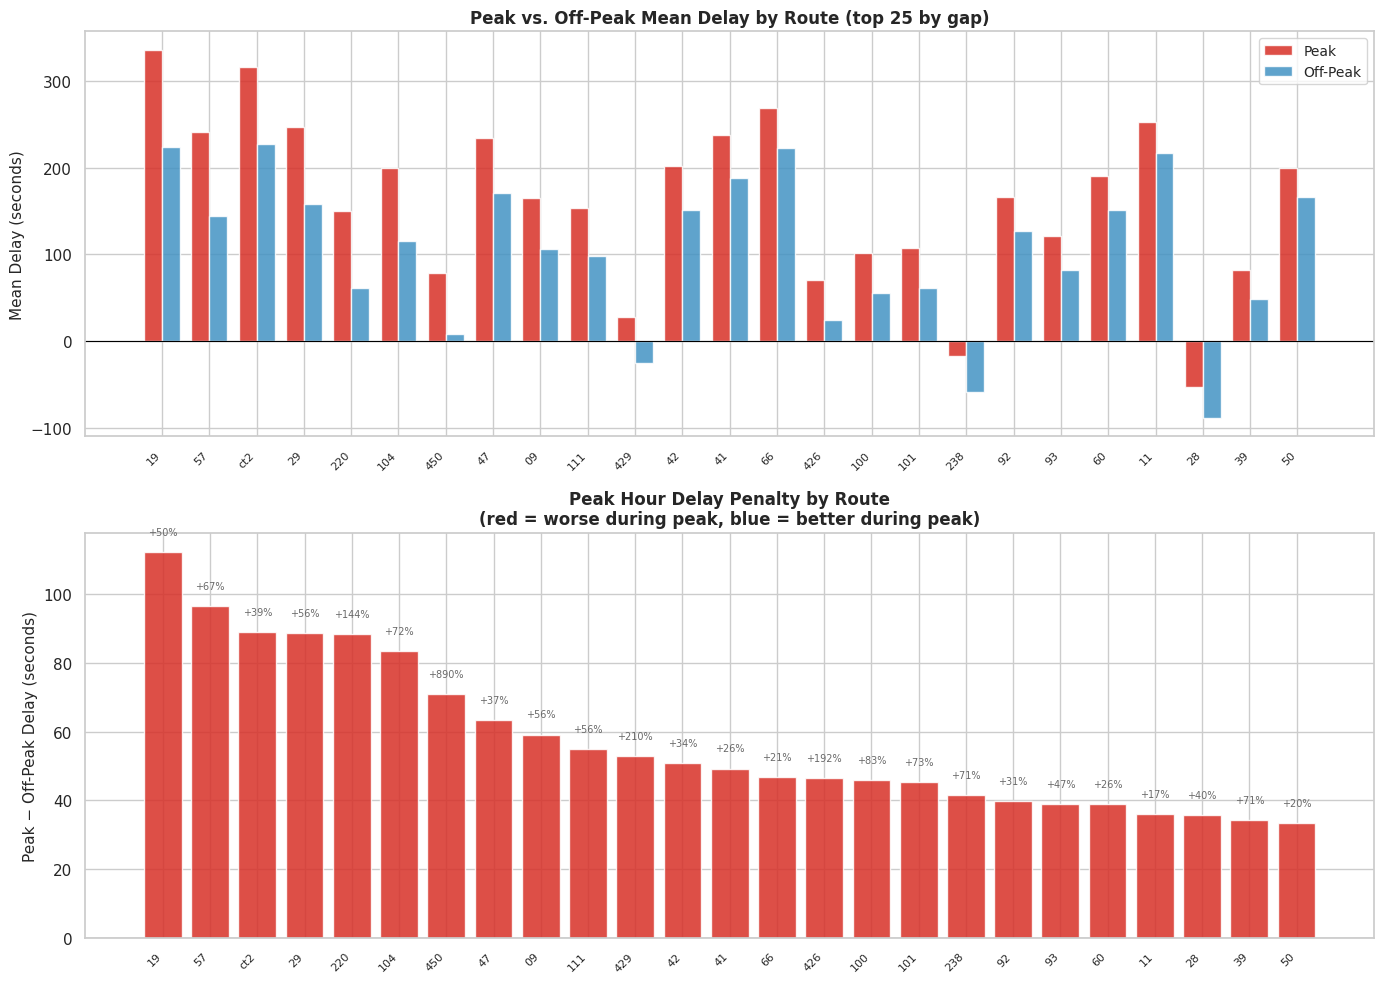


=== Routes with largest peak penalty ===
is_peak       Peak (s)  Off-Peak (s)  Gap (s)  % Worse
route_id_str                                          
19               336.2         223.9    112.3     50.2
57               240.8         144.2     96.5     66.9
ct2              316.7         227.8     88.9     39.0
29               246.6         158.0     88.6     56.1
220              149.7          61.3     88.3    144.0
104              199.4         116.0     83.4     71.9
450               79.0           8.0     71.0    889.6
47               234.0         170.7     63.3     37.1
09               165.7         106.5     59.1     55.5
111              153.1          98.1     55.0     56.0


In [ ]:
# ── C: Peak vs. Off-Peak Delay Gap by Route ─────────────────────────

peak_gap = (
    df.groupby(["route_id_str", "is_peak"])["delay_seconds"]
    .mean()
    .unstack("is_peak")
    .rename(columns={0: "off_peak", 1: "peak"})
    .dropna()
)
peak_gap["gap"] = peak_gap["peak"] - peak_gap["off_peak"]
peak_gap["pct_worse"] = (peak_gap["gap"] / peak_gap["off_peak"].abs().clip(lower=1)) * 100

# Keep routes with enough observations in both conditions
route_counts = df.groupby(["route_id_str", "is_peak"]).size().unstack().dropna()
valid_routes = route_counts[route_counts.min(axis=1) >= 500].index
peak_gap = peak_gap.loc[peak_gap.index.isin(valid_routes)]
peak_gap = peak_gap.sort_values("gap", ascending=False).head(25)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: grouped bar — peak vs. off-peak side by side
x = np.arange(len(peak_gap))
width = 0.38

ax = axes[0]
b1 = ax.bar(x - width/2, peak_gap["peak"],     width, label="Peak",     color="#d73027", alpha=0.85)
b2 = ax.bar(x + width/2, peak_gap["off_peak"], width, label="Off-Peak", color="#4393c3", alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(peak_gap.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean Delay (seconds)", fontsize=11)
ax.set_title("Peak vs. Off-Peak Mean Delay by Route (top 25 by gap)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

# Bottom: gap bar (how much worse is peak?)
ax2 = axes[1]
colors_gap = ["#d73027" if g > 0 else "#4393c3" for g in peak_gap["gap"]]
ax2.bar(x, peak_gap["gap"], color=colors_gap, edgecolor="white", alpha=0.85)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(peak_gap.index, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Peak − Off-Peak Delay (seconds)", fontsize=11)
ax2.set_title("Peak Hour Delay Penalty by Route\n(red = worse during peak, blue = better during peak)", fontsize=12, fontweight="bold")

# Annotate % worse
for i, (gap, pct) in enumerate(zip(peak_gap["gap"], peak_gap["pct_worse"])):
    ax2.text(i, gap + (5 if gap >= 0 else -15),
             f"+{pct:.0f}%" if gap > 0 else f"{pct:.0f}%",
             ha="center", fontsize=7, color="dimgray")

plt.tight_layout()
plt.show()

print("\n=== Routes with largest peak penalty ===")
print(peak_gap[["peak", "off_peak", "gap", "pct_worse"]]
      .rename(columns={"peak": "Peak (s)", "off_peak": "Off-Peak (s)",
                       "gap": "Gap (s)", "pct_worse": "% Worse"})
      .round(1)
      .head(10)
      .to_string())